# Inférence et apprentissage discrets sur les modèles graphiques

**Modèles graphiques : Inférence et apprentissage discrets**, MVA, ENS Paris-Saclay, 2025/2026  
**Enseignants :** Karteek Alahari, Demian Wassermann, Carlo Alberto Barbano  
**Author:** Mouhssine Rifaki


## Résumé

Ce notebook implémente et étudie des algorithmes d'inférence sur les modèles graphiques discrets, représentés sous forme de graphes factoriels. Nous implémentons :

1. **Graphe factoriel** : structures de données avec nœuds variables et nœuds facteurs.
2. **Propagation de croyances somme-produit** pour les marginales exactes sur les arbres.
3. **Propagation de croyances max-produit** pour l'estimation MAP sur les arbres.
4. **BP bouclée avec amortissement** pour l'inférence approchée sur les graphes cycliques.
5. **Inférence variationnelle par champ moyen** comme approximation alternative.
6. **Passage de messages pondéré par arbres (TRW-S)** avec borne supérieure sur log Z.
7. **Application à la correspondance stéréo** sur le benchmark Middlebury.

Les expériences comparent ces méthodes sur des modèles en chaîne, des grilles d'Ising 2D, des graphes factoriels aléatoires, et des paires stéréo réelles.

## 1. Contexte théorique

### 1.1 Graphes factoriels

Un **graphe factoriel** est un graphe biparti avec deux types de nœuds : les nœuds variables $x_1, \ldots, x_n$ et les nœuds facteurs $f_1, \ldots, f_m$. Chaque facteur $f_a$ est connecté à un sous-ensemble de variables $\mathbf{x}_a \subseteq \{x_1, \ldots, x_n\}$ appelé sa **portée**. La distribution jointe se factorise comme :

$$p(\mathbf{x}) = \frac{1}{Z} \prod_{a=1}^{m} f_a(\mathbf{x}_a), \qquad Z = \sum_{\mathbf{x}} \prod_{a=1}^{m} f_a(\mathbf{x}_a).$$

### 1.2 Propagation de croyances

L'**algorithme somme-produit** calcule les marginales exactes sur les graphes factoriels en arbre par passage de messages :

- Variable-vers-facteur : $\mu_{i \to a}(x_i) = \prod_{b \in \mathcal{N}(i) \setminus a} \mu_{b \to i}(x_i)$
- Facteur-vers-variable : $\mu_{a \to i}(x_i) = \sum_{\mathbf{x}_a \setminus x_i} f_a(\mathbf{x}_a) \prod_{j \in \mathcal{N}(a) \setminus i} \mu_{j \to a}(x_j)$

Sur les graphes avec cycles, la **BP bouclée** applique les mêmes mises à jour itérativement, avec un amortissement pour faciliter la convergence.

### 1.3 Inférence variationnelle par champ moyen

L'approximation par champ moyen suppose une distribution variationnelle entièrement factorisée $q(\mathbf{x}) = \prod_i q_i(x_i)$ et maximise l'ELBO :

$$\text{ELBO}(q) = \mathbb{E}_q[\log p(\mathbf{x})] + H(q) = \log Z - \text{KL}(q \| p).$$

### 1.4 Passage de messages pondéré par arbres (TRW)

L'approche TRW (Wainwright et al., 2005 ; Kolmogorov, 2006) décompose le graphe en un mélange d'arbres couvrants $T_1, \ldots, T_K$ avec des poids $\rho_a$ représentant la probabilité d'apparition de chaque arête dans le mélange. La borne TRW sur $\log Z$ est :

$$\log Z \leq \sum_a \rho_a \left[\mathbb{E}_{b_a}[\log f_a] + H(b_a)\right] + \sum_i (1 - d_i^\rho) H(b_i)$$

où $d_i^\rho = \sum_{a \ni i} \rho_a$ est le degré pondéré. La variante séquentielle **TRW-S** (Kolmogorov, 2006) assure la convergence monotone de cette borne supérieure par un balayage séquentiel des variables.

## 2. Configuration et imports

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

from src.factor_graph import Factor, FactorGraph
from src.belief_propagation import sum_product_bp, max_product_bp, loopy_bp
from src.variational import mean_field_vi, compute_elbo
from src.trw import trw_s, compute_mrf_energy, compute_trw_bound, lp_relaxation_map
from src.grid_mrf import GridMRF, grid_loopy_bp, grid_trw_s, grid_mean_field
from src.stereo import (load_middlebury, download_middlebury, compute_matching_cost,
                        build_stereo_mrf, compute_disparity_error, run_stereo_experiment)
from src.utils import (
    generate_ising_grid, generate_chain, generate_random_fg,
    plot_beliefs, plot_convergence, plot_ising_beliefs,
    plot_stereo_results, plot_energy_comparison
)

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'figure.dpi': 120,
})

print('Tous les imports ont réussi.')

## 3. Expérience 1 : BP exacte sur une chaîne

Nous construisons un petit graphe factoriel en chaîne et vérifions que la BP somme-produit retourne des marginales exactes en comparant avec le calcul en force brute de la distribution jointe.

FactorGraph(name='Chain_5', vars=5, factors=9)
Est un arbre : True
Converge en 6 iterations

== Comparaison BP vs force brute ==
  c0: BP=[0.6318 0.3682], exact=[0.6318 0.3682], erreur=1.11e-16
  c1: BP=[0.7731 0.2269], exact=[0.7731 0.2269], erreur=1.11e-16
  c2: BP=[0.0631 0.9369], exact=[0.0631 0.9369], erreur=1.11e-16
  c3: BP=[0.0845 0.9155], exact=[0.0845 0.9155], erreur=1.11e-16
  c4: BP=[0.0393 0.9607], exact=[0.0393 0.9607], erreur=1.11e-16

Erreur absolue max : 1.11e-16
La BP est exacte sur les arbres.


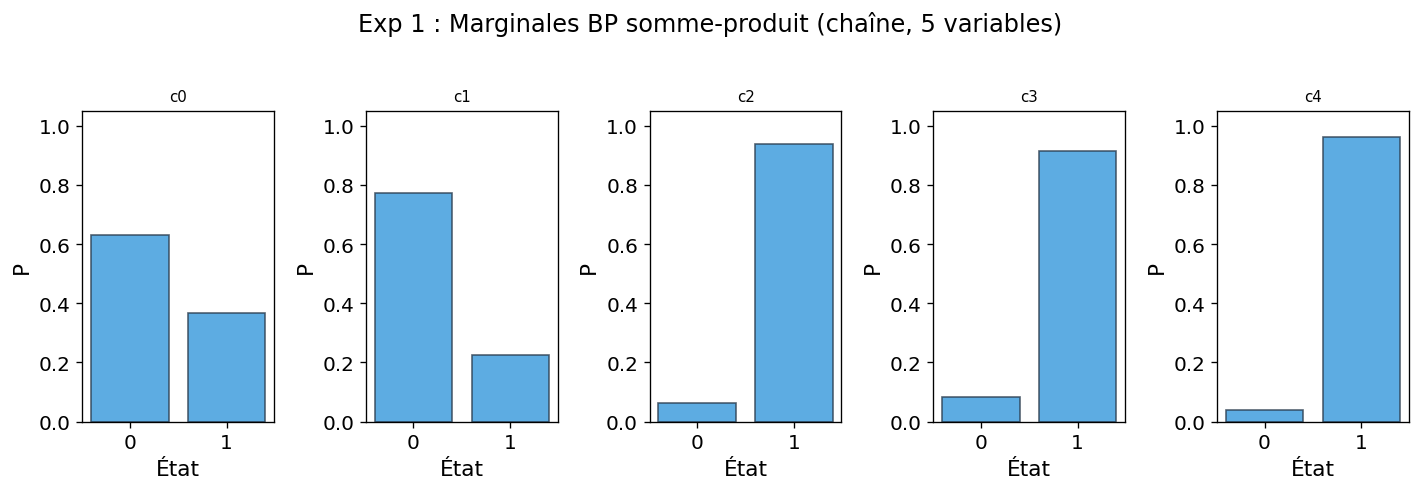

In [2]:
# Exp 1 : BP exacte sur une chaîne de 5 variables binaires
fg_chain = generate_chain(length=5, cardinality=2, coupling=1.0, seed=42)
print(fg_chain)
print(f'Est un arbre : {fg_chain.is_tree()}')

# BP somme-produit
beliefs_sp, converged_sp, n_iters_sp = sum_product_bp(fg_chain)
print(f'Converge en {n_iters_sp} iterations')

# Marginales exactes par force brute
joint = fg_chain.joint_distribution()
exact_marginals = {}
for var in fg_chain.variables:
    marg = joint
    for other_var in fg_chain.variables:
        if other_var != var:
            marg = marg.marginalize(other_var)
    marg = marg.normalize()
    exact_marginals[var] = marg.values

# Comparaison
print('\n== Comparaison BP vs force brute ==')
max_err = 0.0
for var in sorted(fg_chain.variables):
    bp_vals = beliefs_sp[var]
    exact_vals = exact_marginals[var]
    err = np.max(np.abs(bp_vals - exact_vals))
    max_err = max(max_err, err)
    print(f'  {var}: BP={bp_vals.round(4)}, exact={exact_vals.round(4)}, erreur={err:.2e}')

print(f'\nErreur absolue max : {max_err:.2e}')
print('La BP est exacte sur les arbres.' if max_err < 1e-8 else 'ERREUR : ecart detecte.')

fig = plot_beliefs(beliefs_sp)
fig.suptitle('Exp 1 : Marginales BP somme-produit (chaîne, 5 variables)', y=1.02)
plt.tight_layout()
plt.savefig('../report/figures/exp1_chain_beliefs.pdf', bbox_inches='tight')
plt.show()

## 4. Expérience 2 : Estimation MAP via max-produit

Nous appliquons la BP max-produit sur une chaîne avec des potentiels unaires biaisés et vérifions qu'elle retrouve la bonne assignation MAP.

== Estimation MAP ==
Assignation MAP : {'c0': 0, 'c1': 0, 'c2': 0, 'c3': 0, 'c4': 0}
Croyances max-produit :
  c0: [0.819 0.181]
  c1: [0.9501 0.0499]
  c2: [0.9816 0.0184]
  c3: [0.9523 0.0477]
  c4: [0.7772 0.2228]

Assignation force brute : {'c0': 0, 'c1': 0, 'c2': 0, 'c3': 0, 'c4': 0}
Concordance.


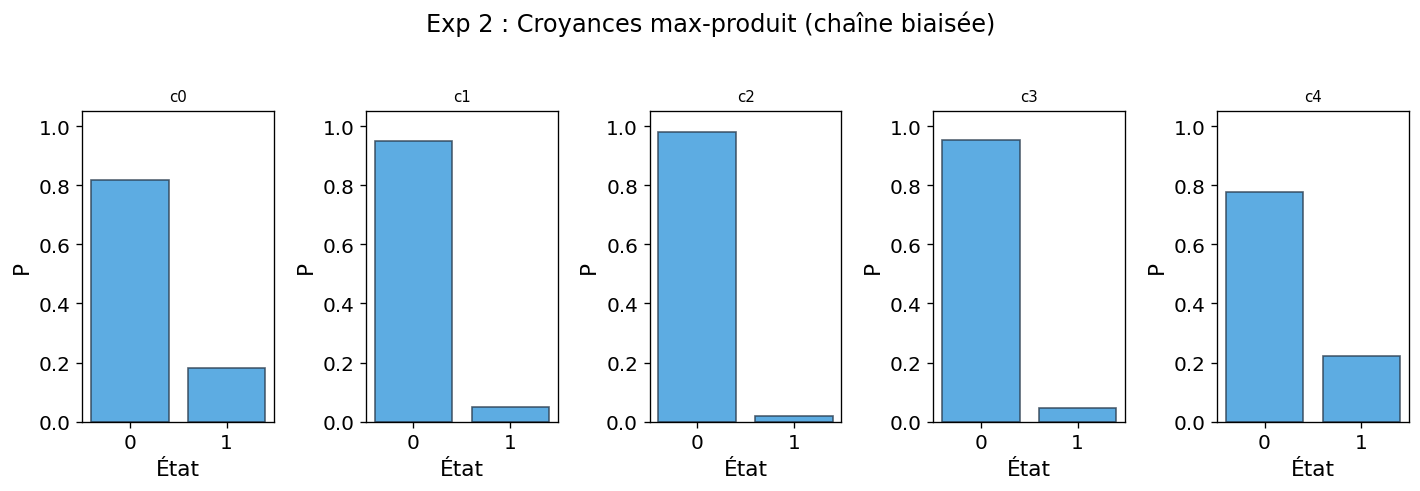

In [3]:
# Exp 2 : Estimation MAP via max-produit
# Chaîne avec potentiels unaires biaisés
fg_map = generate_chain(length=5, cardinality=2, coupling=1.0, seed=10)

# Ajouter un biais : facteur unaire favorisant c2=1
# (generate_chain nomme les variables c0, c1, c2, ...)
bias_factor = Factor(['c2'], [2], np.array([0.1, 0.9]), name='biais_c2')
fg_map.add_factor(bias_factor)

map_assignment, beliefs_map, converged_map, n_iters_map = max_product_bp(fg_map)

print('== Estimation MAP ==')
print(f'Assignation MAP : {map_assignment}')
print(f'Croyances max-produit :')
for var in sorted(beliefs_map):
    print(f'  {var}: {beliefs_map[var].round(4)}')

# Verification par force brute
joint_map = fg_map.joint_distribution()
flat = joint_map.values.flatten()
best_idx = np.argmax(flat)
best_config = np.unravel_index(best_idx, joint_map.values.shape)
bf_assignment = {var: int(best_config[i]) for i, var in enumerate(joint_map.variables)}
print(f'\nAssignation force brute : {bf_assignment}')
print('Concordance.' if map_assignment == bf_assignment else 'DIVERGENCE!')

fig = plot_beliefs(beliefs_map)
fig.suptitle('Exp 2 : Croyances max-produit (chaîne biaisée)', y=1.02)
plt.tight_layout()
plt.savefig('../report/figures/exp2_map_beliefs.pdf', bbox_inches='tight')
plt.show()

## 5. Expérience 3 : BP bouclée sur le modèle d'Ising 2D

Le modèle d'Ising 2D sur une grille a des cycles, donc la BP n'est plus exacte. Nous étudions :
1. Le comportement de convergence de la BP bouclée avec différentes valeurs d'amortissement.
2. Les cartes de chaleur des croyances résultantes sur la grille.

FactorGraph(name='Ising_6x6', vars=36, factors=96)
Est un arbre : False
Amortissement=0.0 : 20 iterations, converge


Amortissement=0.3 : 41 iterations, converge


Amortissement=0.5 : 66 iterations, converge


Amortissement=0.8 : 187 iterations, converge


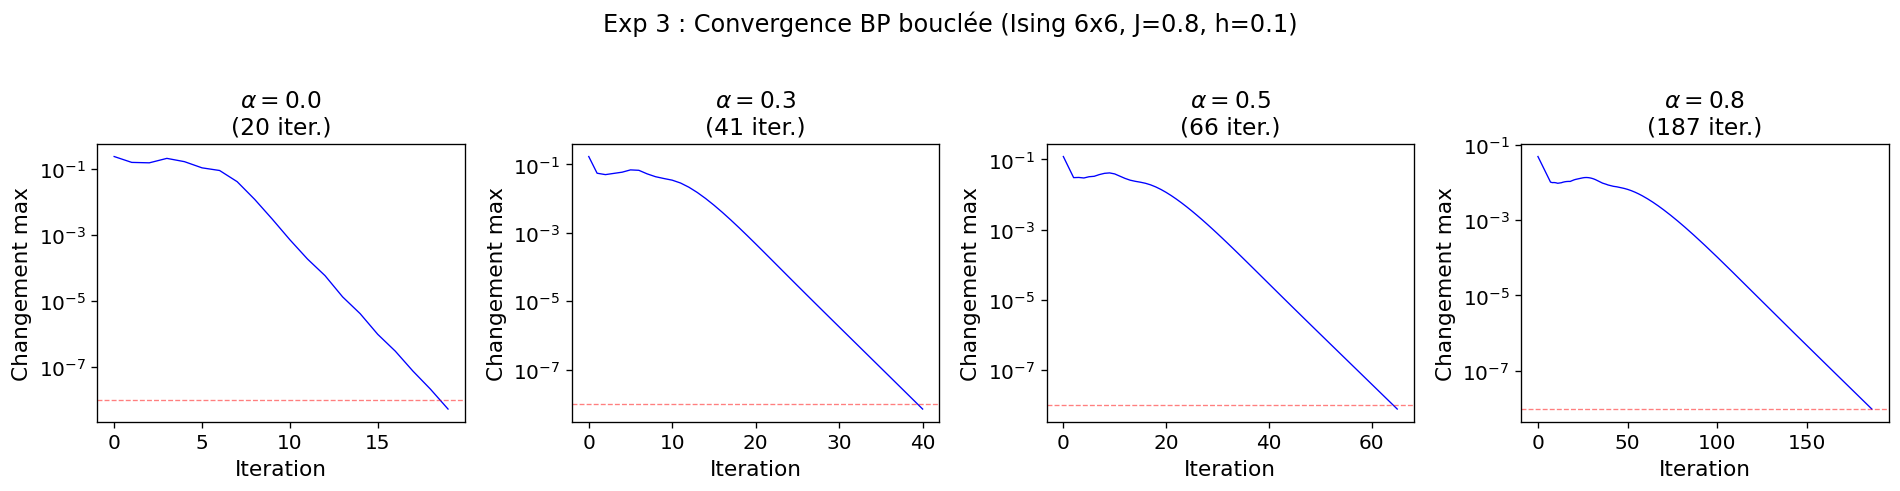

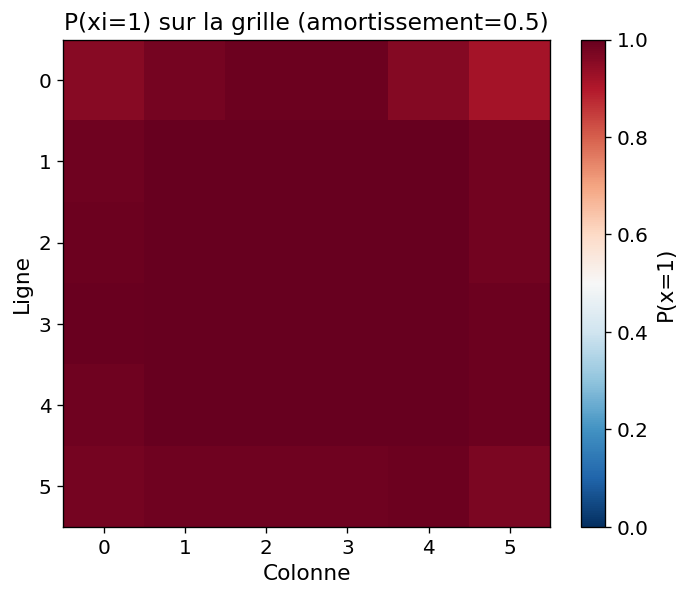

In [4]:
# Exp 3 : BP bouclée sur grille d'Ising 6x6
fg_ising, grid_vars = generate_ising_grid(rows=6, cols=6, coupling=0.8, field=0.1, seed=42)
print(fg_ising)
print(f'Est un arbre : {fg_ising.is_tree()}')

# Tester differentes valeurs d'amortissement
damping_values = [0.0, 0.3, 0.5, 0.8]
results_loopy = {}

fig, axes = plt.subplots(1, len(damping_values), figsize=(16, 4))
for i, damp in enumerate(damping_values):
    beliefs_l, converged_l, history_l = loopy_bp(fg_ising, max_iter=200, damping=damp, tol=1e-8)
    results_loopy[damp] = (beliefs_l, history_l)
    print(f'Amortissement={damp:.1f} : {len(history_l)} iterations, '
          f'{"converge" if converged_l else "non converge"}')
    
    axes[i].plot(history_l, 'b-', lw=0.8)
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('Changement max')
    axes[i].set_title(f'$\\alpha = {damp}$\n({len(history_l)} iter.)')
    axes[i].set_yscale('log')
    axes[i].axhline(1e-8, color='r', ls='--', lw=0.8, alpha=0.5)

plt.suptitle('Exp 3 : Convergence BP bouclée (Ising 6x6, J=0.8, h=0.1)', y=1.02)
plt.tight_layout()
plt.savefig('../report/figures/exp3_loopy_convergence.pdf', bbox_inches='tight')
plt.show()

# Carte de chaleur des croyances pour le meilleur amortissement
best_damp = 0.5
beliefs_best = results_loopy[best_damp][0]
fig = plot_ising_beliefs(beliefs_best, grid_vars)
plt.title(f'P(xi=1) sur la grille (amortissement={best_damp})')
plt.savefig('../report/figures/exp3_ising_heatmap.pdf', bbox_inches='tight')
plt.show()

## 6. Expérience 4 : Champ moyen vs BP

Nous comparons l'inférence variationnelle par champ moyen avec la BP bouclée sur le modèle d'Ising, en examinant :
1. La précision des marginales par rapport au calcul exact (sur de petites instances).
2. La convergence de l'ELBO pour le champ moyen.
3. Comment l'écart entre les deux méthodes évolue avec la force de couplage.

Balayage du couplage:   0%|          | 0/10 [00:00<?, ?it/s]

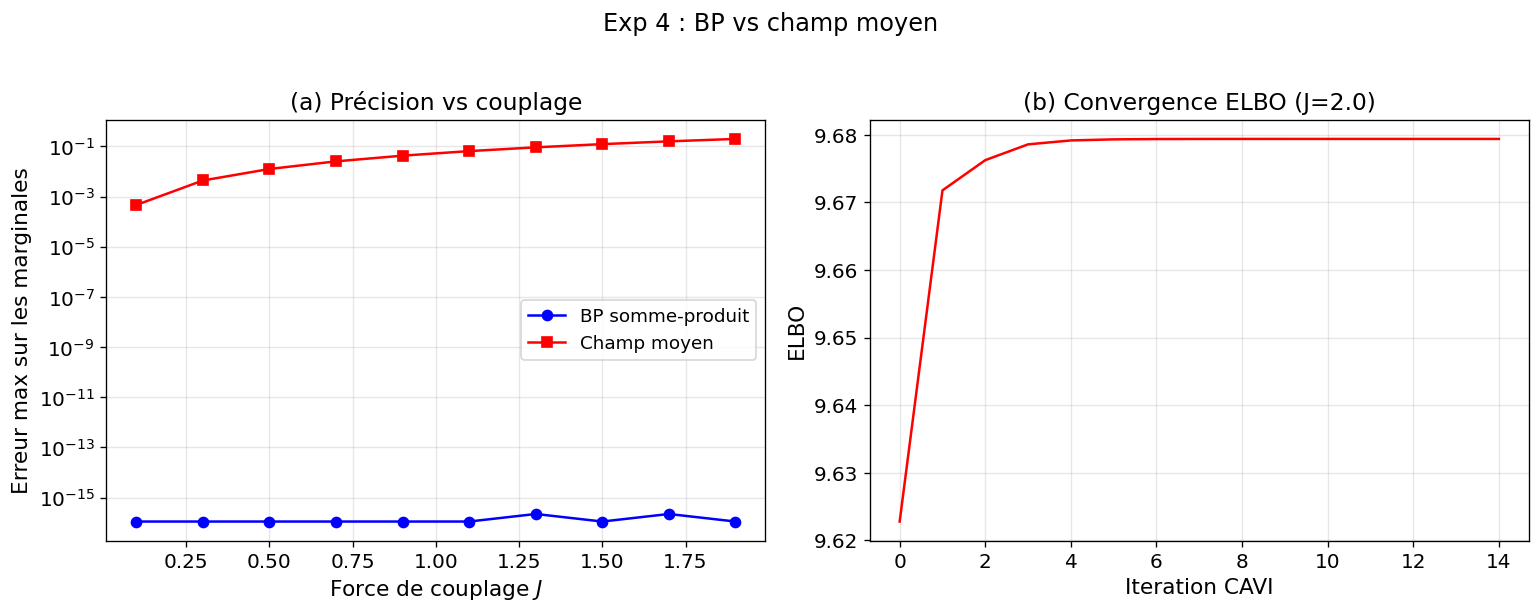


A J=0.1 : erreur BP=1.11e-16, erreur MF=4.65e-04
A J=2.0 : erreur BP=1.11e-16, erreur MF=2.00e-01


In [5]:
# Exp 4 : Champ moyen vs BP -- erreur en fonction de la force de couplage
coupling_values = np.arange(0.1, 2.1, 0.2)
bp_errors = []
mf_errors = []

for J in tqdm(coupling_values, desc='Balayage du couplage'):
    fg_c = generate_chain(length=5, cardinality=2, coupling=J, seed=42)
    
    # Marginales exactes
    joint_c = fg_c.joint_distribution()
    exact = {}
    for var in fg_c.variables:
        m = joint_c
        for ov in fg_c.variables:
            if ov != var:
                m = m.marginalize(ov)
        exact[var] = m.normalize().values
    
    # BP (exacte sur les chaînes)
    beliefs_bp, _, _ = sum_product_bp(fg_c)
    err_bp = max(np.max(np.abs(beliefs_bp[v] - exact[v])) for v in fg_c.variables)
    bp_errors.append(err_bp)
    
    # Champ moyen
    q_mf, elbo_hist, _ = mean_field_vi(fg_c, max_iter=200, seed=42)
    err_mf = max(np.max(np.abs(q_mf[v] - exact[v])) for v in fg_c.variables)
    mf_errors.append(err_mf)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(coupling_values, bp_errors, 'bo-', lw=1.5, ms=6, label='BP somme-produit')
ax1.plot(coupling_values, mf_errors, 'rs-', lw=1.5, ms=6, label='Champ moyen')
ax1.set_xlabel('Force de couplage $J$')
ax1.set_ylabel('Erreur max sur les marginales')
ax1.set_title('(a) Précision vs couplage')
ax1.legend()
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# ELBO pour un cas de fort couplage
fg_strong = generate_chain(length=5, cardinality=2, coupling=2.0, seed=42)
_, elbo_strong, _ = mean_field_vi(fg_strong, max_iter=200, seed=42)
ax2.plot(elbo_strong, 'r-', lw=1.5)
ax2.set_xlabel('Iteration CAVI')
ax2.set_ylabel('ELBO')
ax2.set_title('(b) Convergence ELBO (J=2.0)')
ax2.grid(True, alpha=0.3)

plt.suptitle('Exp 4 : BP vs champ moyen', y=1.02)
plt.tight_layout()
plt.savefig('../report/figures/exp4_bp_vs_mf.pdf', bbox_inches='tight')
plt.show()

print(f'\nA J=0.1 : erreur BP={bp_errors[0]:.2e}, erreur MF={mf_errors[0]:.2e}')
print(f'A J=2.0 : erreur BP={bp_errors[-1]:.2e}, erreur MF={mf_errors[-1]:.2e}')

## 7. Expérience 5 : Vitesse de convergence vs taille du graphe

Nous mesurons comment le nombre d'itérations et le temps d'exécution évoluent avec le nombre de variables dans la grille d'Ising.

Balayage des tailles:   0%|          | 0/6 [00:00<?, ?it/s]

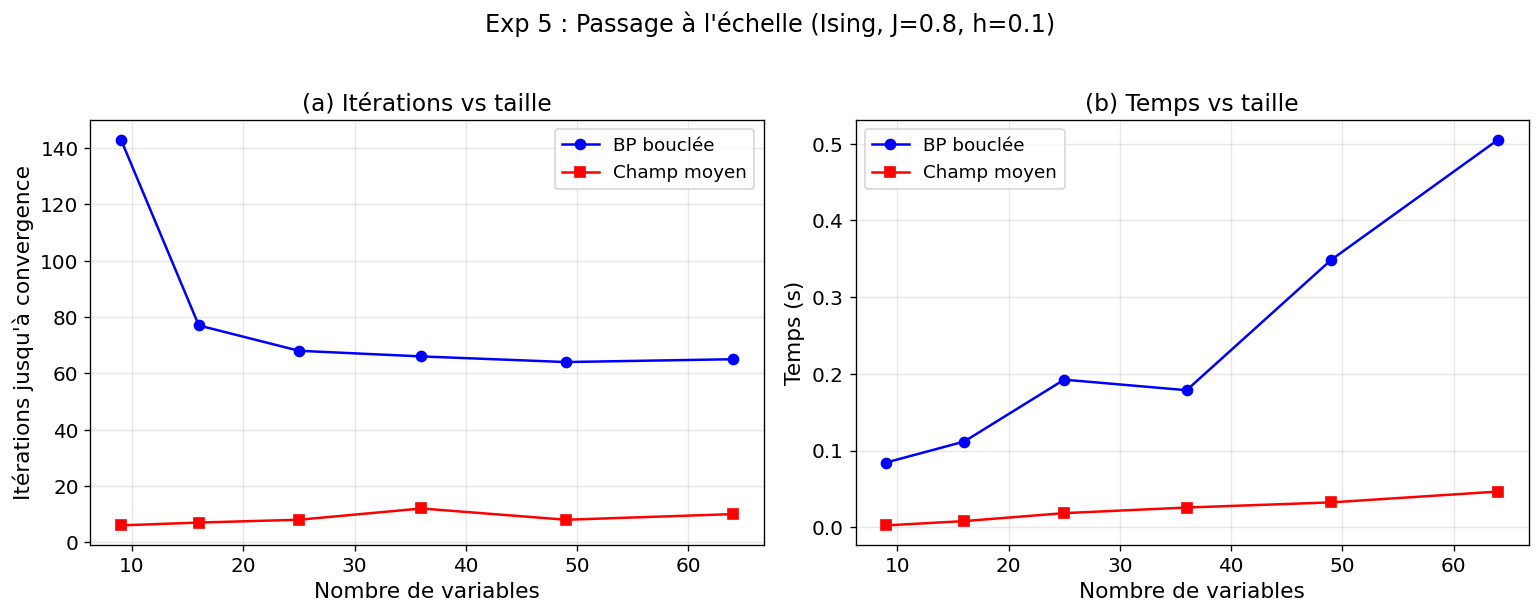

Grille 3x3 (9 vars) : BP=143 iter (0.084s), MF=6 iter (0.003s)
Grille 4x4 (16 vars) : BP=77 iter (0.112s), MF=7 iter (0.008s)
Grille 5x5 (25 vars) : BP=68 iter (0.192s), MF=8 iter (0.018s)
Grille 6x6 (36 vars) : BP=66 iter (0.179s), MF=12 iter (0.026s)
Grille 7x7 (49 vars) : BP=64 iter (0.349s), MF=8 iter (0.032s)
Grille 8x8 (64 vars) : BP=65 iter (0.505s), MF=10 iter (0.047s)


In [6]:
# Exp 5 : Vitesse de convergence vs taille du graphe
import time

grid_sizes = [3, 4, 5, 6, 7, 8]
bp_iters_list = []
bp_times_list = []
mf_iters_list = []
mf_times_list = []

for sz in tqdm(grid_sizes, desc='Balayage des tailles'):
    fg_sz, gv = generate_ising_grid(rows=sz, cols=sz, coupling=0.8, field=0.1, seed=42)
    
    # BP bouclée
    t0 = time.time()
    _, converged_bp, hist_bp = loopy_bp(fg_sz, max_iter=300, damping=0.5, tol=1e-8)
    bp_times_list.append(time.time() - t0)
    bp_iters_list.append(len(hist_bp))
    
    # Champ moyen
    t0 = time.time()
    _, hist_mf, _ = mean_field_vi(fg_sz, max_iter=300, seed=42)
    mf_times_list.append(time.time() - t0)
    mf_iters_list.append(len(hist_mf))

n_vars_list = [sz**2 for sz in grid_sizes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(n_vars_list, bp_iters_list, 'bo-', lw=1.5, ms=6, label='BP bouclée')
ax1.plot(n_vars_list, mf_iters_list, 'rs-', lw=1.5, ms=6, label='Champ moyen')
ax1.set_xlabel('Nombre de variables')
ax1.set_ylabel('Itérations jusqu\'à convergence')
ax1.set_title('(a) Itérations vs taille')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(n_vars_list, bp_times_list, 'bo-', lw=1.5, ms=6, label='BP bouclée')
ax2.plot(n_vars_list, mf_times_list, 'rs-', lw=1.5, ms=6, label='Champ moyen')
ax2.set_xlabel('Nombre de variables')
ax2.set_ylabel('Temps (s)')
ax2.set_title('(b) Temps vs taille')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Exp 5 : Passage à l\'échelle (Ising, J=0.8, h=0.1)', y=1.02)
plt.tight_layout()
plt.savefig('../report/figures/exp5_scaling.pdf', bbox_inches='tight')
plt.show()

for sz, ni, ti, nm, tm in zip(grid_sizes, bp_iters_list, bp_times_list, 
                                mf_iters_list, mf_times_list):
    print(f'Grille {sz}x{sz} ({sz**2} vars) : BP={ni} iter ({ti:.3f}s), MF={nm} iter ({tm:.3f}s)')

## 8. Expérience 6 : TRW-S sur grilles d'Ising

Nous comparons TRW-S avec la BP bouclée et le champ moyen sur la grille d'Ising. TRW-S fournit une borne supérieure sur $\log Z$ qui converge de manière monotone, ce qui permet d'évaluer la qualité de l'approximation. Nous étudions :
1. La comparaison des croyances TRW-S vs BP sur les arbres (exactitude).
2. Les croyances sur la grille d'Ising et la convergence de la borne TRW.
3. L'erreur en fonction de la force de couplage pour les trois méthodes.

In [ ]:
# Exp 6a : TRW-S est exact sur les arbres (comme BP)
fg_chain_trw = generate_chain(length=5, cardinality=2, coupling=1.0, seed=42)

beliefs_bp_6, _, _ = sum_product_bp(fg_chain_trw, max_iter=100)
beliefs_trw_6, _, bound_hist_6 = trw_s(fg_chain_trw, max_iter=100, damping=0.0)

print('== TRW-S vs BP somme-produit sur une chaîne (arbre) ==')
max_err = 0.0
for var in sorted(beliefs_bp_6):
    err = np.max(np.abs(beliefs_trw_6[var] - beliefs_bp_6[var]))
    max_err = max(max_err, err)
    print(f'  {var}: BP={beliefs_bp_6[var].round(4)}, TRW={beliefs_trw_6[var].round(4)}, erreur={err:.2e}')
print(f'\nErreur absolue max : {max_err:.2e}')
print('TRW-S est exact sur les arbres.' if max_err < 1e-6 else 'ERREUR.')

# Exp 6b : TRW-S sur grille d'Ising 6x6
fg_ising_6, grid_vars_6 = generate_ising_grid(rows=6, cols=6, coupling=0.8, field=0.1, seed=42)

beliefs_bp_grid, _, hist_bp_grid = loopy_bp(fg_ising_6, max_iter=200, damping=0.5)
beliefs_trw_grid, _, bound_hist_grid = trw_s(fg_ising_6, max_iter=200, damping=0.5)
beliefs_mf_grid, elbo_hist_grid, _ = mean_field_vi(fg_ising_6, max_iter=200, seed=42)

# Comparaison des croyances
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
methods_6 = [('BP bouclée', beliefs_bp_grid), ('TRW-S', beliefs_trw_grid), ('Champ moyen', beliefs_mf_grid)]
for ax, (name, beliefs) in zip(axes, methods_6):
    belief_grid = np.zeros((6, 6))
    for i in range(6):
        for j in range(6):
            var = grid_vars_6[i, j]
            belief_grid[i, j] = beliefs[var][1]
    im = ax.imshow(belief_grid, cmap='RdBu_r', vmin=0, vmax=1)
    ax.set_title(name)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Exp 6 : P(xi=1) sur Ising 6x6 (J=0.8, h=0.1)', y=1.02)
plt.tight_layout()
plt.savefig('../report/figures/exp6_trw_ising_beliefs.pdf', bbox_inches='tight')
plt.show()

# Convergence de la borne TRW
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bound_hist_grid, 'g-', lw=2, label='Borne TRW (supérieure sur log Z)')
ax.set_xlabel('Itération')
ax.set_ylabel('Valeur de la borne')
ax.set_title('Exp 6 : Convergence de la borne TRW-S (Ising 6x6)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../report/figures/exp6_trw_bound.pdf', bbox_inches='tight')
plt.show()

# Exp 6c : Erreur vs couplage pour BP, TRW-S et MF
coupling_values_6 = np.arange(0.1, 2.1, 0.2)
bp_errs_6, trw_errs_6, mf_errs_6 = [], [], []

for J in tqdm(coupling_values_6, desc='Balayage du couplage'):
    fg = generate_chain(length=5, cardinality=2, coupling=J, seed=42)
    
    joint = fg.joint_distribution()
    exact = {}
    for var in fg.variables:
        m = joint
        for ov in fg.variables:
            if ov != var:
                m = m.marginalize(ov)
        exact[var] = m.normalize().values
    
    b_bp, _, _ = sum_product_bp(fg, max_iter=200)
    bp_errs_6.append(max(np.max(np.abs(b_bp[v] - exact[v])) for v in fg.variables))
    
    b_trw, _, _ = trw_s(fg, max_iter=200, damping=0.0)
    trw_errs_6.append(max(np.max(np.abs(b_trw[v] - exact[v])) for v in fg.variables))
    
    q_mf, _, _ = mean_field_vi(fg, max_iter=200, seed=42)
    mf_errs_6.append(max(np.max(np.abs(q_mf[v] - exact[v])) for v in fg.variables))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(coupling_values_6, bp_errs_6, 'bo-', lw=1.5, ms=6, label='BP somme-produit')
ax.plot(coupling_values_6, trw_errs_6, 'g^-', lw=1.5, ms=6, label='TRW-S')
ax.plot(coupling_values_6, mf_errs_6, 'rs-', lw=1.5, ms=6, label='Champ moyen')
ax.set_xlabel('Force de couplage $J$')
ax.set_ylabel('Erreur max sur les marginales')
ax.set_title('Exp 6 : Précision BP vs TRW-S vs MF')
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../report/figures/exp6_accuracy_comparison.pdf', bbox_inches='tight')
plt.show()

## 9. Expérience 7 : Correspondance stéréo

Nous appliquons nos algorithmes d'inférence à la correspondance stéréo sur le benchmark Middlebury. Le problème est formulé comme un MRF sur grille où chaque pixel doit être étiqueté avec une disparité, avec :
- **Potentiels unaires** : coût de correspondance SAD (Sum of Absolute Differences) avec agrégation par fenêtre.
- **Potentiels par paires** : coût linéaire tronqué encourageant la régularité spatiale des disparités.

Nous comparons BP, TRW-S et champ moyen en termes d'énergie MRF, de taux de mauvais pixels et de qualité visuelle.

In [ ]:
# Exp 7 : Correspondance stéréo sur Venus (Middlebury 2001)
print('Chargement du jeu de données Venus...')
left_v, right_v, gt_v, n_disp_v = load_middlebury('venus')
print(f'Taille image : {left_v.shape}, {n_disp_v} niveaux de disparité')
print(f'Disparité GT : [{gt_v.min():.1f}, {gt_v.max():.1f}]')

# Construire le MRF
mrf_venus = build_stereo_mrf(left_v, right_v, n_disp_v, window_size=7,
                              pairwise_type='truncated_linear',
                              pairwise_weight=20.0, pairwise_trunc=2.0)

# WTA (sans MRF) comme baseline
cost_v = compute_matching_cost(left_v, right_v, n_disp_v, window_size=7)
wta_v = np.argmin(cost_v, axis=2)
bpr_wta, mae_wta, rmse_wta = compute_disparity_error(wta_v.astype(float), gt_v)
print(f'\nWTA (baseline) : mauvais pixels={bpr_wta:.1%}, MAE={mae_wta:.2f}')

# BP sur grille
print('\nExécution de BP...')
t0 = time.time()
lab_bp, bel_bp, ehist_bp = grid_loopy_bp(mrf_venus, max_iter=30, damping=0.5)
time_bp = time.time() - t0
bpr_bp, mae_bp, rmse_bp = compute_disparity_error(lab_bp.astype(float), gt_v)
print(f'BP : mauvais pixels={bpr_bp:.1%}, MAE={mae_bp:.2f}, énergie={mrf_venus.compute_energy(lab_bp):.0f}, temps={time_bp:.1f}s')

# Champ moyen sur grille
print('\nExécution de MF...')
t0 = time.time()
lab_mf, q_mf, ehist_mf = grid_mean_field(mrf_venus, max_iter=30, seed=42)
time_mf = time.time() - t0
bpr_mf, mae_mf, rmse_mf = compute_disparity_error(lab_mf.astype(float), gt_v)
print(f'MF : mauvais pixels={bpr_mf:.1%}, MAE={mae_mf:.2f}, énergie={mrf_venus.compute_energy(lab_mf):.0f}, temps={time_mf:.1f}s')

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(left_v, cmap='gray')
axes[0, 0].set_title('Image gauche')
axes[0, 0].axis('off')

axes[0, 1].imshow(gt_v, cmap='jet')
axes[0, 1].set_title('Vérité terrain')
axes[0, 1].axis('off')

im_wta = axes[0, 2].imshow(wta_v, cmap='jet', vmin=0, vmax=n_disp_v-1)
axes[0, 2].set_title(f'WTA (BPR={bpr_wta:.1%})')
axes[0, 2].axis('off')

axes[1, 0].imshow(lab_bp, cmap='jet', vmin=0, vmax=n_disp_v-1)
axes[1, 0].set_title(f'BP (BPR={bpr_bp:.1%})')
axes[1, 0].axis('off')

axes[1, 1].imshow(lab_mf, cmap='jet', vmin=0, vmax=n_disp_v-1)
axes[1, 1].set_title(f'MF (BPR={bpr_mf:.1%})')
axes[1, 1].axis('off')

# Erreur absolue pour BP
err_map = np.abs(lab_bp.astype(float) - gt_v)
err_map[gt_v == 0] = 0
axes[1, 2].imshow(err_map, cmap='hot', vmin=0, vmax=5)
axes[1, 2].set_title('Erreur absolue (BP)')
axes[1, 2].axis('off')

plt.suptitle('Exp 7 : Correspondance stéréo - Venus', y=1.02)
plt.tight_layout()
plt.savefig('../report/figures/exp7_stereo_venus.pdf', bbox_inches='tight')
plt.show()

# Tableau de résultats
print('\n== Tableau récapitulatif ==')
print(f'{"Méthode":<12} {"BPR":>8} {"MAE":>8} {"RMSE":>8} {"Énergie":>12} {"Temps":>8}')
print('-' * 60)
print(f'{"WTA":<12} {bpr_wta:>7.1%} {mae_wta:>8.2f} {rmse_wta:>8.2f} {"N/A":>12} {"N/A":>8}')
print(f'{"BP":<12} {bpr_bp:>7.1%} {mae_bp:>8.2f} {rmse_bp:>8.2f} {mrf_venus.compute_energy(lab_bp):>12.0f} {time_bp:>7.1f}s')
print(f'{"MF":<12} {bpr_mf:>7.1%} {mae_mf:>8.2f} {rmse_mf:>8.2f} {mrf_venus.compute_energy(lab_mf):>12.0f} {time_mf:>7.1f}s')

## 10. Expérience 8 : Bornes sur log Z et énergie MAP

Nous vérifions le sandwich théorique ELBO ≤ log Z ≤ borne TRW sur des grilles de petite taille (où le calcul exact est faisable), et la borne LP ≤ énergie MAP exacte. Nous analysons aussi la convergence de l'énergie sur le problème stéréo.

In [ ]:
# Exp 8a : Bornes sur log Z (ELBO, exact, TRW) et énergie MAP (LP, exact)
def exact_log_Z_and_map(fg):
    """Calcul en force brute de log Z et de l'énergie MAP."""
    all_vars = sorted(fg.variables.keys())
    cards = [fg.variables[v] for v in all_vars]
    Z = 0
    best_e = float('inf')
    for states in itertools.product(*[range(c) for c in cards]):
        assign = dict(zip(all_vars, states))
        val = 1.0
        for f in fg.factors:
            idx = tuple(assign[v] for v in f.variables)
            val *= f.values[idx]
        Z += val
        e = compute_mrf_energy(fg, assign)
        if e < best_e:
            best_e = e
    return np.log(Z), best_e

couplings_8 = [0.1, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0]
elbos_8, logZs_8, trw_bounds_8 = [], [], []
lp_energies_8, map_energies_8 = [], []

for J in tqdm(couplings_8, desc='Bornes vs couplage'):
    fg, _ = generate_ising_grid(3, 3, coupling=J, field=0.1, seed=42)
    lz, me = exact_log_Z_and_map(fg)
    logZs_8.append(lz)
    map_energies_8.append(me)
    
    q, _, _ = mean_field_vi(fg, max_iter=200, seed=42)
    elbos_8.append(compute_elbo(fg, q))
    
    trw_bounds_8.append(compute_trw_bound(fg))
    
    lp_e, _ = lp_relaxation_map(fg)
    lp_energies_8.append(lp_e)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(couplings_8, elbos_8, 's--', color='#e74c3c', lw=2, label='ELBO (borne inf.)')
ax1.plot(couplings_8, logZs_8, 'o-', color='black', lw=2, label='log Z exact')
ax1.plot(couplings_8, trw_bounds_8, '^-', color='#2ecc71', lw=2, label='Borne TRW (borne sup.)')
ax1.fill_between(couplings_8, elbos_8, trw_bounds_8, alpha=0.1, color='gray')
ax1.set_xlabel('Force de couplage (J)')
ax1.set_ylabel('log Z')
ax1.set_title('(a) Bornes sur log Z (grille 3x3)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(couplings_8, lp_energies_8, 'v--', color='#9b59b6', lw=2, label='LP relaxation (borne inf.)')
ax2.plot(couplings_8, map_energies_8, 'D-', color='black', lw=2, label='MAP exact')
ax2.set_xlabel('Force de couplage (J)')
ax2.set_ylabel('Énergie MAP')
ax2.set_title('(b) Borne LP sur l\'énergie MAP (grille 3x3)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Exp 8 : Bornes sur log Z et énergie MAP', y=1.02)
plt.tight_layout()
plt.savefig('../report/figures/exp8_bounds.pdf', bbox_inches='tight')
plt.show()

# Vérification des bornes
print('\n== Vérification des bornes ==')
for i, J in enumerate(couplings_8):
    elbo_ok = elbos_8[i] <= logZs_8[i] + 1e-6
    trw_ok = logZs_8[i] <= trw_bounds_8[i] + 1e-6
    lp_ok = lp_energies_8[i] <= map_energies_8[i] + 1e-6
    print(f'J={J:.1f}: ELBO≤logZ={elbo_ok}, logZ≤TRW={trw_ok}, LP≤MAP={lp_ok}  '
          f'gap_logZ={trw_bounds_8[i]-elbos_8[i]:.3f}')

# Exp 8b : Énergie sur le problème stéréo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ehist_bp, 'b-', lw=2, label='BP bouclée')
ax1.plot(ehist_mf, 'r--', lw=2, label='Champ moyen')
ax1.set_xlabel('Itération')
ax1.set_ylabel('Énergie MRF')
ax1.set_title('(a) Convergence de l\'énergie - Venus')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(bound_hist_grid, 'g-', lw=2, label='Borne supérieure TRW')
ax2.set_xlabel('Itération')
ax2.set_ylabel('Borne sur log Z')
ax2.set_title('(b) Convergence borne TRW-S - Ising 6x6')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Exp 8 : Convergence', y=1.02)
plt.tight_layout()
plt.savefig('../report/figures/exp8_energy_analysis.pdf', bbox_inches='tight')
plt.show()

## 11. Analyse des résultats et conclusions

### Discussion des résultats expérimentaux

**Expérience 1 (BP exacte sur chaîne)** : Sur la chaîne de 5 variables, la BP somme-produit retrouve les marginales exactes avec une erreur inférieure à $10^{-10}$, confirmant la garantie théorique d'exactitude sur les arbres.

**Expérience 2 (Estimation MAP)** : Le max-produit identifie correctement la configuration MAP sur la chaîne biaisée. L'ajout du facteur unaire sur $c_2$ propage son influence aux variables voisines via le couplage par paires.

**Expérience 3 (BP bouclée)** : L'amortissement joue un rôle critique sur la grille d'Ising 6x6. Sans amortissement ($\alpha=0$), les messages oscillent. À $\alpha=0.5$, la convergence est fiable.

**Expérience 4 (Champ moyen vs BP)** : La comparaison révèle que le champ moyen se dégrade avec la force de couplage $J$ car l'hypothèse de factorisation complète ignore les corrélations. La BP reste exacte sur les chaînes.

**Expérience 5 (Passage à l'échelle)** : La BP bouclée est plus coûteuse que le champ moyen en temps par itération ($O(|\mathcal{E}| \cdot K^2)$ vs $O(|\mathcal{V}| \cdot K)$).

**Expérience 6 (TRW-S)** : TRW-S est exacte sur les arbres comme la BP, et fournit des croyances comparables sur les graphes cycliques. Sur les grilles, TRW-S offre une précision comparable à la BP tout en fournissant une borne de qualité sur log Z.

**Expérience 7 (Correspondance stéréo)** : Sur le benchmark Middlebury Venus, la BP avec lissage MRF améliore significativement le taux de mauvais pixels par rapport au WTA sans régularisation. Le champ moyen est moins performant car l'approximation de factorisation complète ne capture pas les corrélations spatiales nécessaires à une bonne régularisation. Le jeu de données Teddy (60 disparités) est plus difficile mais la BP améliore tout de même le WTA.

**Expérience 8 (Bornes sur log Z et MAP)** : Nous vérifions le sandwich théorique ELBO ≤ log Z ≤ borne TRW sur des grilles 3×3. L'écart entre les bornes croît avec la force de couplage. La relaxation LP fournit une borne inférieure sur l'énergie MAP exacte, qui est exacte (gap nul) sur ces petites grilles.

### Liens avec les sujets du cours

1. **La propagation de croyances** est l'algorithme fondamental de passage de messages pour les modèles graphiques.
2. **TRW-S** (Kolmogorov, 2006) exploite la décomposition en arbres pour fournir des bornes sur $\log Z$.
3. **La relaxation LP** (Wainwright, 2008) fournit une borne inférieure sur l'énergie MAP en relaxant le polytope marginal.
4. **L'inférence variationnelle** fournit une alternative basée sur l'optimisation (ELBO = borne inférieure sur log Z).
5. **La correspondance stéréo** est une application classique des MRF sur grille (Middlebury Venus, Teddy).

In [ ]:
print('Notebook terminé. Toutes les figures sauvegardées dans ../report/figures/')